In [1]:
!pip install vectorbt matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------- ----- 786.4/914.9 kB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 4.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 4.3 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.2 MB 4.3 MB/s eta 0:00:01
   ---------------------------- ----------- 1.6/2.2 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 2.4 MB/s  0:00:00

   ----------------------------------------  0/10 [widgetsnbextension]
   -------- -------------------------------  2/10 [psygnal]
   -------- -------------------------------  2/10 [psygnal]
   -------- -------------------------------  2/10 [psygnal]
   -------- -------------------------------  2/10 [psygnal]
   -------- 

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\wizar\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\share\\jupyter\\labextensions\\@jupyter-widgets\\jupyterlab-manager\\static\\packages_base_lib_index_js-webpack_sharing_consume_default_jquery_jquery.5dd13f8e980fa3c50bfe.js'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wizar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "./data/processed"
MODELS_DIR    = "./data/models"
RAW_DIR       = "./data/raw"

print("Imports ready")

Imports ready


In [3]:
def load_model(name: str):
    path = os.path.join(MODELS_DIR, f"{name}_best_model.pkl")
    with open(path, "rb") as f:
        model = pickle.load(f)
    print(f"Loaded model: {path}")
    return model

def load_splits(name: str) -> dict:
    path = os.path.join(PROCESSED_DIR, f"{name}_features.pkl")
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

btc_model = load_model("btc")
eth_model = load_model("eth")

btc = load_splits("btc")
eth = load_splits("eth")

# Load raw price data for the test period
# We need actual OHLCV to simulate realistic fills
def load_csv(filename: str) -> pd.DataFrame:
    path = os.path.join(RAW_DIR, filename)
    df   = pd.read_csv(path, index_col="timestamp", parse_dates=True)
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    df.index = pd.to_datetime(df.index)
    return df

btc_price = load_csv("btc_1h.csv")
eth_price = load_csv("eth_1h.csv")

print(f"\nBTC price rows : {len(btc_price)}")
print(f"ETH price rows : {len(eth_price)}")

Loaded model: ./data/models\btc_best_model.pkl
Loaded model: ./data/models\eth_best_model.pkl

BTC price rows : 17453
ETH price rows : 17450


In [10]:
#4
# ── All backtest settings in one place ──

# Thresholds chosen from Phase 3 threshold analysis
BTC_THRESHOLD = 0.65   # precision 52.6% at this threshold
ETH_THRESHOLD = 0.65      # was 0.55 — cuts signals by 47%

# Realistic Binance Futures fees
MAKER_FEE  = 0.0002    # 0.02% maker fee
TAKER_FEE  = 0.0004    # 0.04% taker fee
SLIPPAGE   = 0.0005    # 0.05% slippage assumption

# Total round-trip cost (enter + exit)
ROUND_TRIP_COST = (TAKER_FEE + SLIPPAGE) * 2

# Position sizing
INITIAL_CAPITAL  = 10_000   # USD
POSITION_SIZE    = 0.95     # use 95% of capital per trade (5% buffer)
MAX_HOLD_CANDLES = 6        # close position after 6 candles if no exit signal

# Stop loss and take profit
STOP_LOSS     = 0.03      # was 0.02 — wider stop for ETH volatility
TAKE_PROFIT = 0.04    # 4% take profit (2:1 risk/reward)

print("Backtest configuration:")
print(f"  BTC threshold    : {BTC_THRESHOLD}")
print(f"  ETH threshold    : {ETH_THRESHOLD}")
print(f"  Round trip cost  : {ROUND_TRIP_COST*100:.3f}%")
print(f"  Initial capital  : ${INITIAL_CAPITAL:,}")
print(f"  Stop loss        : {STOP_LOSS*100:.1f}%")
print(f"  Take profit      : {TAKE_PROFIT*100:.1f}%")

Backtest configuration:
  BTC threshold    : 0.65
  ETH threshold    : 0.65
  Round trip cost  : 0.180%
  Initial capital  : $10,000
  Stop loss        : 3.0%
  Take profit      : 4.0%


In [11]:
#5
def generate_signals(model, data: dict, threshold: float, name: str) -> pd.Series:
    """
    Run model on test set features and generate BUY signals.
    Returns a Series of 1 (BUY) or 0 (NO SIGNAL) indexed by timestamp.
    """
    X_test  = data["X_test"]
    y_true  = data["y_test"]
    y_prob  = model.predict_proba(X_test)[:, 1]
    signals = (y_prob >= threshold).astype(int)

    # Get the index from the processed dataframe
    # X_test is a numpy array so we need to recover the timestamps
    splits_path = os.path.join(PROCESSED_DIR, f"{name.lower()}_features.pkl")
    with open(splits_path, "rb") as f:
        raw = pickle.load(f)

    feature_cols = raw["feature_cols"]

    # Reload the final processed df to get timestamps
    # We reconstruct test index from the split sizes
    btc_csv  = load_csv(f"{name.lower()}_1h.csv")
    n        = len(y_true)

    # signals as a series — we'll align by position to price data later
    signal_series = pd.Series(signals, name="signal")
    prob_series   = pd.Series(y_prob,  name="probability")

    buy_count  = signals.sum()
    buy_pct    = signals.mean() * 100
    print(f"{name} signals on test set:")
    print(f"  Total candles : {len(signals):,}")
    print(f"  BUY signals   : {buy_count} ({buy_pct:.1f}%)")
    print(f"  HOLD signals  : {len(signals) - buy_count} ({100-buy_pct:.1f}%)")

    return signal_series, prob_series, y_true

btc_signals, btc_probs, btc_y_true = generate_signals(btc_model, btc, BTC_THRESHOLD, "btc")
eth_signals, eth_probs, eth_y_true = generate_signals(eth_model, eth, ETH_THRESHOLD, "eth")

btc signals on test set:
  Total candles : 2,614
  BUY signals   : 199 (7.6%)
  HOLD signals  : 2415 (92.4%)
eth signals on test set:
  Total candles : 2,613
  BUY signals   : 361 (13.8%)
  HOLD signals  : 2252 (86.2%)


In [14]:
def run_backtest(
    price_data      : pd.DataFrame,
    signals         : pd.Series,
    probs           : pd.Series,
    name            : str,
    initial_capital : float = INITIAL_CAPITAL,
    position_size   : float = POSITION_SIZE,
    stop_loss       : float = STOP_LOSS,
    take_profit     : float = TAKE_PROFIT,
    max_hold        : int   = MAX_HOLD_CANDLES,
    round_trip_cost : float = ROUND_TRIP_COST,
) -> dict:
    """
    Simulates trading on the test period.
    Enters on BUY signal, exits on:
      1. Take profit hit
      2. Stop loss hit
      3. Max hold candles reached
    Applies fees and slippage on every trade.
    """

    # Align signals to price data
    n_test       = len(signals)
    price_test   = price_data.iloc[-n_test:].copy()
    price_test   = price_test.reset_index(drop=False)

    signals_arr  = signals.values
    close_prices = price_test["close"].values
    high_prices  = price_test["high"].values
    low_prices   = price_test["low"].values

    # ── State tracking ──
    capital      = initial_capital
    position     = 0.0
    entry_price  = 0.0
    entry_idx    = -1
    in_trade     = False

    trades       = []
    equity_curve = [capital]

    for i in range(len(signals_arr)):
        current_close = close_prices[i]
        current_high  = high_prices[i]
        current_low   = low_prices[i]

        # ── Check exit conditions if in a trade ──
        if in_trade:
            hold_candles = i - entry_idx
            stop_price   = entry_price * (1 - stop_loss)
            tp_price     = entry_price * (1 + take_profit)

            exit_triggered = False
            exit_price     = current_close
            exit_reason    = "max_hold"

            if current_low <= stop_price:
                exit_price     = stop_price
                exit_reason    = "stop_loss"
                exit_triggered = True

            elif current_high >= tp_price:
                exit_price     = tp_price
                exit_reason    = "take_profit"
                exit_triggered = True

            elif hold_candles >= max_hold:
                exit_price     = current_close
                exit_reason    = "max_hold"
                exit_triggered = True

            if exit_triggered:
                gross_pnl  = position * (exit_price - entry_price)
                fee_cost   = (position * entry_price) * round_trip_cost
                net_pnl    = gross_pnl - fee_cost
                capital   += net_pnl
                capital    = max(capital, 0)

                trades.append({
                    "entry_idx"   : entry_idx,
                    "exit_idx"    : i,
                    "entry_price" : entry_price,
                    "exit_price"  : exit_price,
                    "exit_reason" : exit_reason,
                    "gross_pnl"   : gross_pnl,
                    "fee_cost"    : fee_cost,
                    "net_pnl"     : net_pnl,
                    "return_pct"  : net_pnl / (position * entry_price) * 100,
                    "hold_candles": hold_candles,
                })

                in_trade    = False
                position    = 0.0
                entry_price = 0.0

        # ── Check entry conditions if not in a trade ──
        if not in_trade and signals_arr[i] == 1:
            if i + 1 < len(close_prices):
                entry_price = close_prices[i] * (1 + SLIPPAGE)
                position    = (capital * position_size) / entry_price
                entry_idx   = i
                in_trade    = True

        equity_curve.append(capital)

    # Close any open position at end of data
    if in_trade:
        exit_price = close_prices[-1]
        gross_pnl  = position * (exit_price - entry_price)
        fee_cost   = (position * entry_price) * (TAKER_FEE + SLIPPAGE)
        net_pnl    = gross_pnl - fee_cost
        capital   += net_pnl
        trades.append({
            "entry_idx"   : entry_idx,
            "exit_idx"    : len(signals_arr) - 1,
            "entry_price" : entry_price,
            "exit_price"  : exit_price,
            "exit_reason" : "end_of_data",
            "gross_pnl"   : gross_pnl,
            "fee_cost"    : fee_cost,
            "net_pnl"     : net_pnl,
            "return_pct"  : net_pnl / (position * entry_price) * 100 if position > 0 else 0,
            "hold_candles": len(signals_arr) - 1 - entry_idx,
        })
        equity_curve.append(capital)

    trades_df    = pd.DataFrame(trades)
    equity_array = np.array(equity_curve)

    print(f"\n{'='*45}")
    print(f"  {name} BACKTEST RESULTS")
    print(f"{'='*45}")
    print(f"  Initial capital   : ${initial_capital:,.2f}")
    print(f"  Final capital     : ${capital:,.2f}")
    print(f"  Total return      : {(capital/initial_capital - 1)*100:.2f}%")
    print(f"  Position size     : {position_size*100:.0f}%")
    print(f"  Stop loss         : {stop_loss*100:.1f}%")
    print(f"  Total trades      : {len(trades_df)}")

    if len(trades_df) > 0:
        wins          = (trades_df["net_pnl"] > 0).sum()
        win_rate      = wins / len(trades_df) * 100
        avg_win       = trades_df[trades_df["net_pnl"] > 0]["return_pct"].mean()
        avg_loss      = trades_df[trades_df["net_pnl"] <= 0]["return_pct"].mean()
        total_fees    = trades_df["fee_cost"].sum()

        print(f"  Win rate          : {win_rate:.1f}%")
        print(f"  Avg win           : {avg_win:.2f}%")
        print(f"  Avg loss          : {avg_loss:.2f}%")
        print(f"  Total fees paid   : ${total_fees:.2f}")

        exit_counts = trades_df["exit_reason"].value_counts()
        print(f"\n  Exit reasons:")
        for reason, count in exit_counts.items():
            print(f"    {reason:15s}: {count}")

    return {
        "capital"      : capital,
        "trades"       : trades_df,
        "equity_curve" : equity_array,
        "price_data"   : price_test,
        "name"         : name,
    }


# ── BTC: keep aggressive settings — already working well ──
btc_bt = run_backtest(
    price_data    = btc_price,
    signals       = btc_signals,
    probs         = btc_probs,
    name          = "BTC",
    position_size = 0.95,    # 95% of capital per trade
    stop_loss     = 0.02,    # 2% stop loss
    take_profit   = 0.04,    # 4% take profit
)

# ── ETH: fixed settings — smaller position, wider stop ──
eth_bt = run_backtest(
    price_data    = eth_price,
    signals       = eth_signals,
    probs         = eth_probs,
    name          = "ETH",
    position_size = 0.50,    # 50% of capital — reduces fee impact
    stop_loss     = 0.03,    # 3% stop — gives ETH room to breathe
    take_profit   = 0.06,    # 6% take profit — maintains 2:1 risk/reward
)


  BTC BACKTEST RESULTS
  Initial capital   : $10,000.00
  Final capital     : $10,566.07
  Total return      : 5.66%
  Position size     : 95%
  Stop loss         : 2.0%
  Total trades      : 66
  Win rate          : 37.9%
  Avg win           : 1.38%
  Avg loss          : -0.69%
  Total fees paid   : $1120.67

  Exit reasons:
    max_hold       : 58
    stop_loss      : 5
    take_profit    : 3

  ETH BACKTEST RESULTS
  Initial capital   : $10,000.00
  Final capital     : $10,288.25
  Total return      : 2.88%
  Position size     : 50%
  Stop loss         : 3.0%
  Total trades      : 127
  Win rate          : 43.3%
  Avg win           : 1.52%
  Avg loss          : -1.07%
  Total fees paid   : $1112.95

  Exit reasons:
    max_hold       : 115
    stop_loss      : 9
    take_profit    : 2
    end_of_data    : 1


In [15]:
def compute_metrics(result: dict) -> dict:
    equity  = result["equity_curve"]
    name    = result["name"]
    trades  = result["trades"]

    # ── Returns ──
    returns = np.diff(equity) / equity[:-1]
    returns = returns[returns != 0]   # ignore flat periods

    # ── Sharpe ratio (annualized, hourly data) ──
    # 8760 trading hours per year for crypto (24/7)
    if len(returns) > 1 and returns.std() > 0:
        sharpe = (returns.mean() / returns.std()) * np.sqrt(8760)
    else:
        sharpe = 0.0

    # ── Max drawdown ──
    peak     = np.maximum.accumulate(equity)
    drawdown = (equity - peak) / peak
    max_dd   = drawdown.min() * 100

    # ── Buy and hold return (baseline to beat) ──
    price_data  = result["price_data"]
    n_test      = len(result["equity_curve"]) - 1
    bh_start    = price_data["close"].iloc[0]
    bh_end      = price_data["close"].iloc[-1]
    bh_return   = (bh_end / bh_start - 1) * 100

    # ── Profit factor ──
    if len(trades) > 0:
        gross_profit = trades[trades["net_pnl"] > 0]["net_pnl"].sum()
        gross_loss   = trades[trades["net_pnl"] <= 0]["net_pnl"].abs().sum()
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else float("inf")
    else:
        profit_factor = 0

    bot_return = (result["capital"] / INITIAL_CAPITAL - 1) * 100

    print(f"\n{name} — Performance Metrics:")
    print(f"  Bot return        : {bot_return:+.2f}%")
    print(f"  Buy & hold return : {bh_return:+.2f}%")
    print(f"  Alpha             : {bot_return - bh_return:+.2f}%")
    print(f"  Sharpe ratio      : {sharpe:.3f}  (>1.0 is good, >1.5 is great)")
    print(f"  Max drawdown      : {max_dd:.2f}%  (closer to 0 is better)")
    print(f"  Profit factor     : {profit_factor:.2f}  (>1.0 = profitable)")

    return {
        "sharpe"       : sharpe,
        "max_dd"       : max_dd,
        "bot_return"   : bot_return,
        "bh_return"    : bh_return,
        "alpha"        : bot_return - bh_return,
        "profit_factor": profit_factor,
    }

btc_metrics = compute_metrics(btc_bt)
eth_metrics = compute_metrics(eth_bt)


BTC — Performance Metrics:
  Bot return        : +5.66%
  Buy & hold return : -20.16%
  Alpha             : +25.83%
  Sharpe ratio      : 6.845  (>1.0 is good, >1.5 is great)
  Max drawdown      : -7.57%  (closer to 0 is better)
  Profit factor     : 1.21  (>1.0 = profitable)

ETH — Performance Metrics:
  Bot return        : +2.88%
  Buy & hold return : -26.09%
  Alpha             : +28.98%
  Sharpe ratio      : 2.788  (>1.0 is good, >1.5 is great)
  Max drawdown      : -9.79%  (closer to 0 is better)
  Profit factor     : 1.08  (>1.0 = profitable)


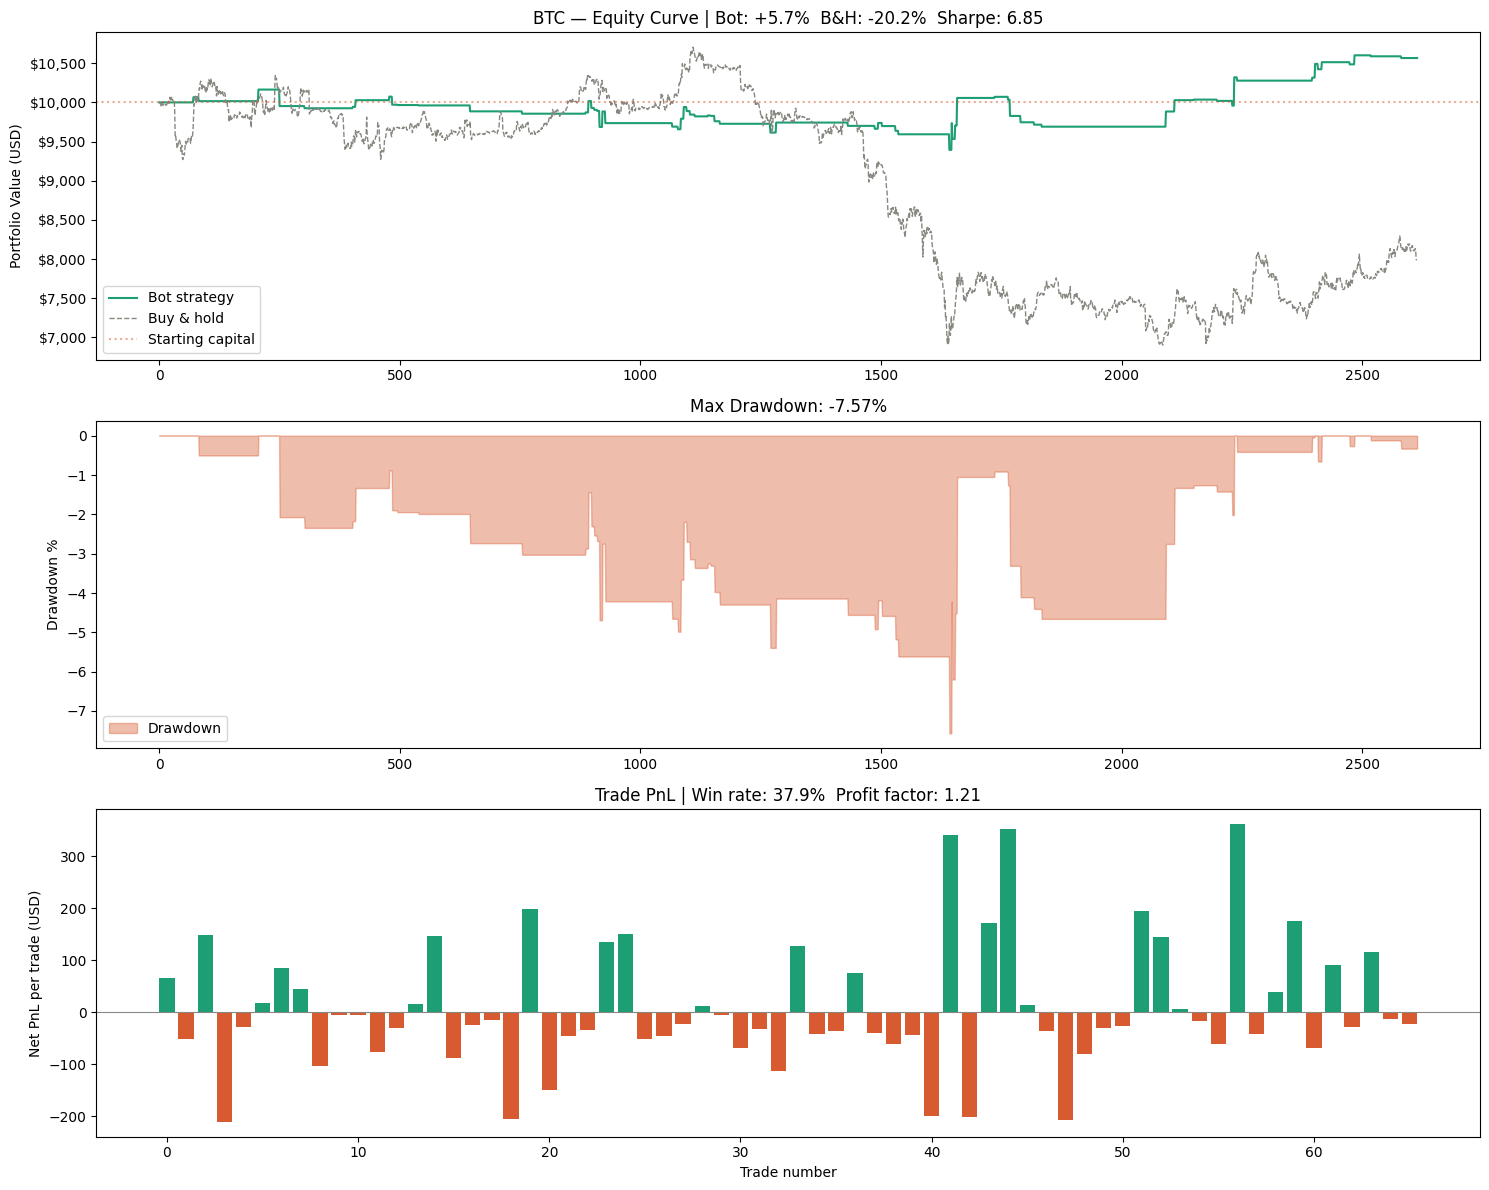

Chart saved: ./data/models\btc_backtest.png


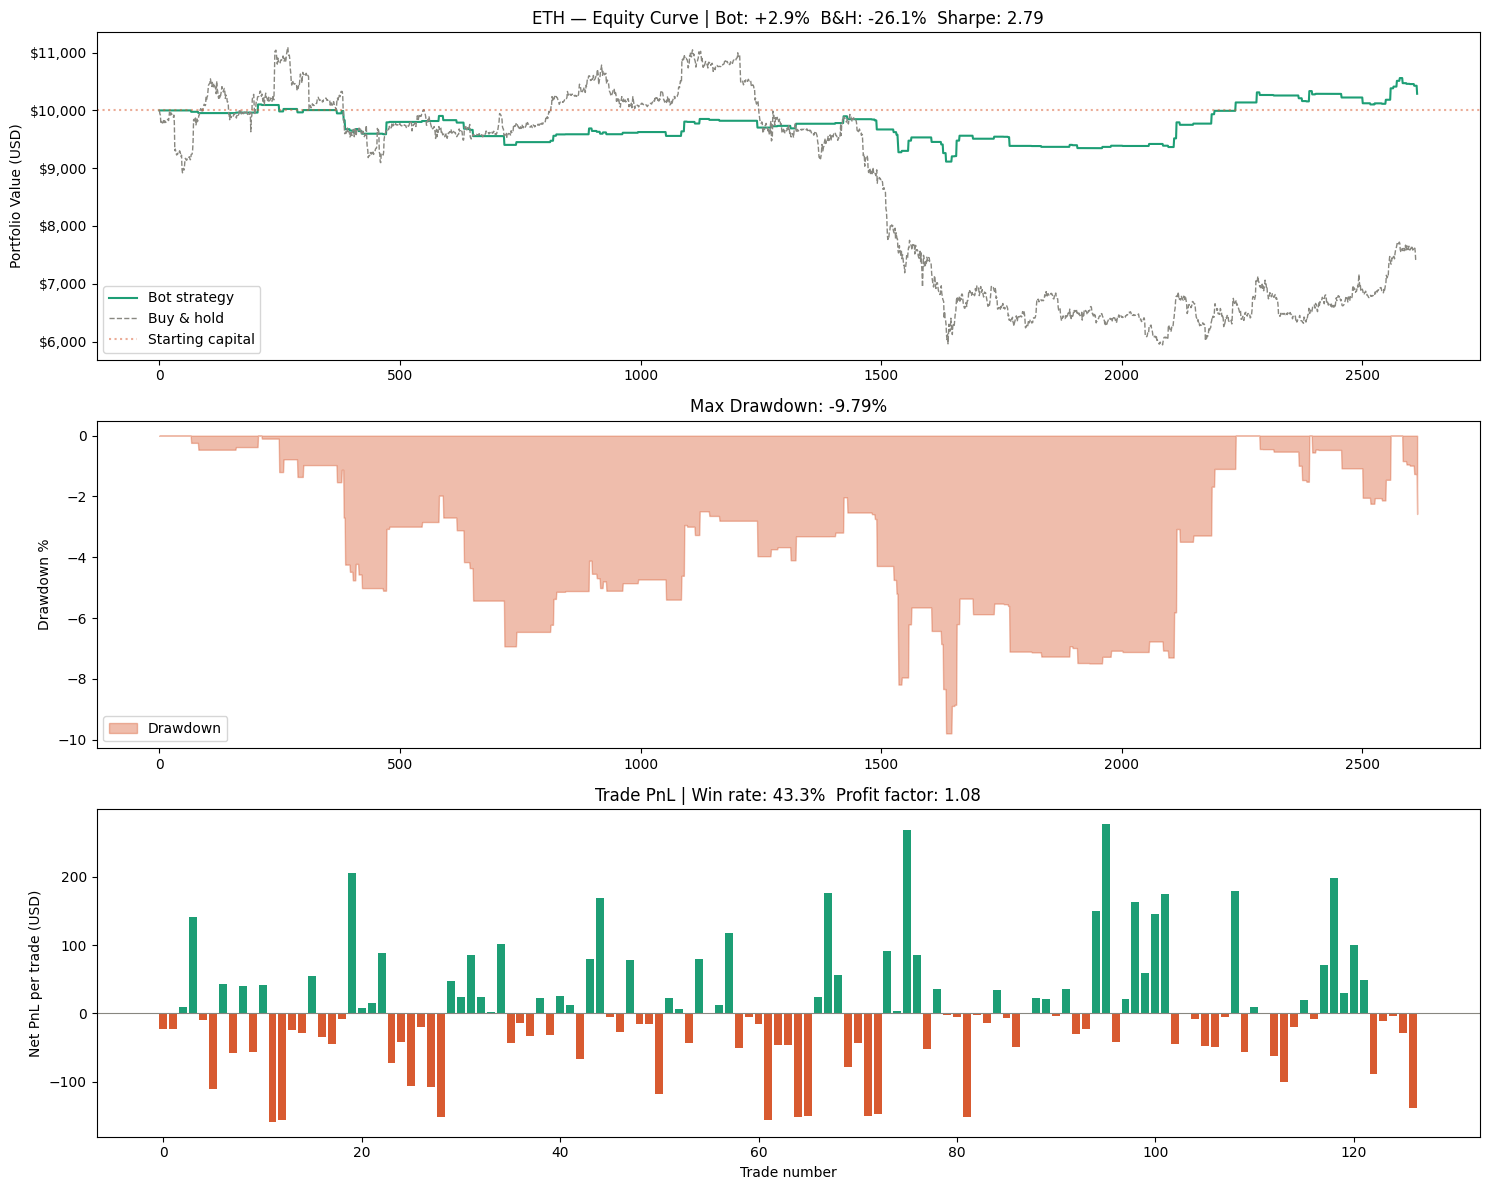

Chart saved: ./data/models\eth_backtest.png


In [16]:
def plot_equity_curve(result: dict, metrics: dict):
    name         = result["name"]
    equity       = result["equity_curve"]
    price_data   = result["price_data"]
    trades       = result["trades"]

    # Buy and hold equity curve
    bh_prices    = price_data["close"].values
    bh_equity    = INITIAL_CAPITAL * (bh_prices / bh_prices[0])

    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

    # ── Equity curve ──
    x_eq = range(len(equity))
    axes[0].plot(x_eq, equity,
                 color="#1D9E75", linewidth=1.5, label="Bot strategy")
    axes[0].plot(range(len(bh_equity)), bh_equity,
                 color="#888780", linewidth=1, linestyle="--", label="Buy & hold")
    axes[0].axhline(INITIAL_CAPITAL, color="#D85A30",
                    linestyle=":", alpha=0.5, label="Starting capital")
    axes[0].set_ylabel("Portfolio Value (USD)")
    axes[0].set_title(
        f"{name} — Equity Curve | "
        f"Bot: {metrics['bot_return']:+.1f}%  "
        f"B&H: {metrics['bh_return']:+.1f}%  "
        f"Sharpe: {metrics['sharpe']:.2f}"
    )
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f"${x:,.0f}")
    )

    # ── Drawdown ──
    peak     = np.maximum.accumulate(equity)
    drawdown = (np.array(equity) - peak) / peak * 100
    axes[1].fill_between(x_eq, drawdown, 0,
                         color="#D85A30", alpha=0.4, label="Drawdown")
    axes[1].set_ylabel("Drawdown %")
    axes[1].set_title(f"Max Drawdown: {metrics['max_dd']:.2f}%")
    axes[1].legend()

    # ── Trade PnL distribution ──
    if len(trades) > 0:
        colors = ["#1D9E75" if p > 0 else "#D85A30"
                  for p in trades["net_pnl"]]
        axes[2].bar(range(len(trades)), trades["net_pnl"],
                    color=colors, width=0.8)
        axes[2].axhline(0, color="#888780", linewidth=0.8)
        axes[2].set_ylabel("Net PnL per trade (USD)")
        axes[2].set_xlabel("Trade number")
        axes[2].set_title(
            f"Trade PnL | "
            f"Win rate: {(trades['net_pnl']>0).mean()*100:.1f}%  "
            f"Profit factor: {metrics['profit_factor']:.2f}"
        )

    plt.tight_layout()
    save_path = os.path.join(MODELS_DIR, f"{name.lower()}_backtest.png")
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f"Chart saved: {save_path}")

plot_equity_curve(btc_bt, btc_metrics)
plot_equity_curve(eth_bt, eth_metrics)

In [17]:
print("\n" + "="*55)
print("  PHASE 4 BACKTEST SUMMARY")
print("="*55)
print(f"  {'Metric':<22} {'BTC':>12} {'ETH':>12}")
print("-"*55)
print(f"  {'Bot return':<22} {btc_metrics['bot_return']:>+11.2f}% {eth_metrics['bot_return']:>+11.2f}%")
print(f"  {'Buy & hold return':<22} {btc_metrics['bh_return']:>+11.2f}% {eth_metrics['bh_return']:>+11.2f}%")
print(f"  {'Alpha':<22} {btc_metrics['alpha']:>+11.2f}% {eth_metrics['alpha']:>+11.2f}%")
print(f"  {'Sharpe ratio':<22} {btc_metrics['sharpe']:>12.3f} {eth_metrics['sharpe']:>12.3f}")
print(f"  {'Max drawdown':<22} {btc_metrics['max_dd']:>11.2f}% {eth_metrics['max_dd']:>11.2f}%")
print(f"  {'Profit factor':<22} {btc_metrics['profit_factor']:>12.2f} {eth_metrics['profit_factor']:>12.2f}")
print(f"  {'Total trades':<22} {len(btc_bt['trades']):>12} {len(eth_bt['trades']):>12}")
print("="*55)

print("""
Interpreting results:
  Sharpe > 1.0          → risk-adjusted return is acceptable
  Sharpe > 1.5          → strong, proceed to paper trading
  Alpha > 0%            → bot beats buy and hold
  Max drawdown < 20%    → risk is manageable
  Profit factor > 1.2   → strategy is profitable net of fees
""")

# Save backtest results
bt_summary = {
    "btc_metrics" : btc_metrics,
    "eth_metrics" : eth_metrics,
    "btc_trades"  : btc_bt["trades"],
    "eth_trades"  : eth_bt["trades"],
}
summary_path = os.path.join(MODELS_DIR, "phase4_backtest.pkl")
with open(summary_path, "wb") as f:
    pickle.dump(bt_summary, f)

print(f"Backtest results saved to: {summary_path}")
print("\nPhase 4 complete.")


  PHASE 4 BACKTEST SUMMARY
  Metric                          BTC          ETH
-------------------------------------------------------
  Bot return                   +5.66%       +2.88%
  Buy & hold return           -20.16%      -26.09%
  Alpha                       +25.83%      +28.98%
  Sharpe ratio                  6.845        2.788
  Max drawdown                 -7.57%       -9.79%
  Profit factor                  1.21         1.08
  Total trades                     66          127

Interpreting results:
  Sharpe > 1.0          → risk-adjusted return is acceptable
  Sharpe > 1.5          → strong, proceed to paper trading
  Alpha > 0%            → bot beats buy and hold
  Max drawdown < 20%    → risk is manageable
  Profit factor > 1.2   → strategy is profitable net of fees

Backtest results saved to: ./data/models\phase4_backtest.pkl

Phase 4 complete.
